# Full pipeline: scrape -> merge -> forecast

End-to-end notebook combining four previously separate notebooks:

1. `fundamentals/python files/macrotrends_scraping.ipynb` — scrape quarterly fundamentals from Macrotrends.
2. `macro/python/macro_data.ipynb` — fetch quarterly GDP growth and Fed Funds rate.
3. `prices/python/stock_prices.ipynb` — fetch monthly stock price via yfinance.
4. `models/<ticker>/Prophet_arima.ipynb` — forecast fundamentals (ARIMA vs. ARDL, best model per metric), then forecast price with Prophet using those fundamentals as regressors.

Set `TICKER` in the **Config** cell and run top to bottom to reproduce the full pipeline for any of the companies already in this repo, or a new one (add it to `TICKER_SLUGS` first).

**Fix vs. the original notebooks:** the old `merged_stock_data.ipynb` joined fundamentals to macro data by row *position* (`merge(..., left_index=True, right_index=True)`), which silently desynchronizes everything downstream if a single quarter is missing from either source. This version joins on the actual date (nearest calendar quarter-end, since fiscal quarter-end dates rarely match calendar quarter-end dates exactly) via `pd.merge_asof`.

In [1]:
import io
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
import pmdarima as pm
import yfinance as yf
from fredapi import Fred
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.ardl import ardl_select_order

try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass  # python-dotenv is optional; falls back to real environment variables


/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


## Config

Everything ticker-specific lives here. `TICKER_SLUGS` maps a ticker to its Macrotrends URL slug
(`TICKER/company-name`) — add an entry here before running a new company.

In [2]:
TICKER = "AAPL"

TICKER_SLUGS = {
    "AAPL": "AAPL/apple",
    "MSFT": "MSFT/microsoft",
    "TSLA": "TSLA/tesla",
    "NKE": "NKE/nike",
    "AMD": "AMD/amd",
    "CRM": "CRM/salesforce",
    "ADBE": "ADBE/adobe",
    "HNST": "HNST/honest-company",
}

FUTURE_PERIODS = 4          # quarters to forecast forward
BACKTEST_PERIODS = 4        # quarters held out for backtesting (same horizon as FUTURE_PERIODS)
FREQ = "QE"                 # quarter-end frequency (pandas >= 2.2 spelling; "Q" still works but is deprecated)
PRICE_HISTORY = "17y"       # how far back to pull price history from yfinance
MACRO_TOLERANCE_DAYS = 40   # max gap allowed when matching fundamentals to a macro quarter

REG_COLS = [
    "revenue_musd", "net_income_musd", "total_assets_musd",
    "total_liabilities_musd", "share_holder_equity_musd",
]

FRED_API_KEY = os.environ.get("FRED_API_KEY")
if not FRED_API_KEY:
    raise RuntimeError(
        "FRED_API_KEY is not set. Get a free key at https://fred.stlouisfed.org/docs/api/api_key.html "
        "and either `export FRED_API_KEY=...` before launching Jupyter, or put it in a local .env file "
        "(FRED_API_KEY=...) next to this notebook."
    )

if TICKER not in TICKER_SLUGS:
    raise KeyError(f"No Macrotrends slug configured for {TICKER!r}. Add it to TICKER_SLUGS first.")

BASE_DIR = Path(".").resolve()
FUND_DIR = BASE_DIR / "fundamentals_cache"
MACRO_DIR = BASE_DIR / "macro_cache"
PRICE_DIR = BASE_DIR / "price_cache"
for d in (FUND_DIR, MACRO_DIR, PRICE_DIR):
    d.mkdir(exist_ok=True)


## Step 1 — Fundamentals (Macrotrends scraping)

Same scraping logic as `macrotrends_scraping.ipynb`, wrapped in a function that takes a ticker
instead of editing the notebook by hand, and returns a dataframe instead of only writing CSVs.

In [3]:
def _scrape_metric(slug: str, page: str, col_key: str, value_col: str) -> pd.DataFrame:
    """Scrape one Macrotrends metric page and return its quarterly series as a tidy dataframe."""
    url = f"https://www.macrotrends.net/stocks/charts/{slug}/{page}"
    headers = {"User-Agent": "Mozilla/5.0"}
    html = requests.get(url, headers=headers, timeout=30).text
    soup = BeautifulSoup(html, "html.parser")

    tables = soup.select("table.historical_data_table.table")
    if len(tables) < 2:
        raise RuntimeError(f"Expected an annual + quarterly table on {url}, found {len(tables)}.")

    # tables[0] is annual, tables[1] is quarterly (there may be extra tables further down the
    # page, e.g. sector/competitor info -- those are ignored)
    df = pd.read_html(io.StringIO(str(tables[1])))[0]
    df.columns = ["date", col_key]
    df[value_col] = (
        df[col_key].astype(str).str.replace("$", "", regex=False).str.replace(",", "", regex=False).astype(float)
    )
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    return df[["date", value_col]].dropna(subset=["date"]).sort_values("date").reset_index(drop=True)


METRIC_PAGES = {
    "revenue_musd": ("revenue", "revenue"),
    "net_income_musd": ("net-income", "net income"),
    "total_assets_musd": ("total-assets", "total assets"),
    "total_liabilities_musd": ("total-liabilities", "total liabilities"),
    "share_holder_equity_musd": ("total-share-holder-equity", "share holder equity"),
}


def fetch_fundamentals(ticker: str, *, use_cache: bool = True) -> pd.DataFrame:
    """Scrape quarterly revenue/net income/assets/liabilities/equity for `ticker` from Macrotrends."""
    slug = TICKER_SLUGS[ticker]
    cache_path = FUND_DIR / f"{ticker.lower()}_quarterly_all_metrics.csv"
    if use_cache and cache_path.exists():
        return pd.read_csv(cache_path, parse_dates=["date"])

    merged = None
    for value_col, (page, col_key) in METRIC_PAGES.items():
        metric_df = _scrape_metric(slug, page, col_key, value_col)
        merged = metric_df if merged is None else pd.merge(merged, metric_df, on="date", how="outer")
        time.sleep(1)  # be polite to macrotrends.net between requests

    merged = merged.sort_values("date").reset_index(drop=True)
    merged.to_csv(cache_path, index=False)
    return merged


fundamentals_df = fetch_fundamentals(TICKER)
fundamentals_df.tail()


,date,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd
55,2025-03-31,95359.0,24780.0,331233.0,264437.0,66796.0
56,2025-06-30,94036.0,23434.0,331495.0,265665.0,65830.0
57,2025-09-30,102466.0,27466.0,359241.0,285508.0,73733.0
58,2025-12-31,143756.0,42097.0,379297.0,291107.0,88190.0
59,2026-03-31,111184.0,29578.0,371082.0,264591.0,106491.0


## Step 2 — Macro data (GDP growth + Fed Funds rate)

Identical to `macro_data.ipynb`. This data is **not** ticker-specific, so it is cached once and
reused for every company instead of being re-fetched per ticker.

In [4]:
def fetch_macro_data(*, use_cache: bool = True) -> pd.DataFrame:
    """Quarterly US real GDP growth (multpl.com) merged with the effective Fed Funds rate (FRED)."""
    cache_path = MACRO_DIR / "macro_quarterly.csv"
    if use_cache and cache_path.exists():
        return pd.read_csv(cache_path, parse_dates=["date"])

    # --- GDP growth ---
    gdp = pd.read_html("https://www.multpl.com/us-real-gdp-growth-rate/table/by-quarter")[0]
    gdp.columns = ["date", "gdp_growth"]
    gdp["date"] = pd.to_datetime(gdp["date"], format="%b %d, %Y")
    gdp["gdp_growth"] = (
        gdp["gdp_growth"].astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False).astype(float)
    )
    # multpl labels each row with the last day of the *previous* month; snap it to the nearest
    # calendar quarter-end (e.g. 2009-02-28 reporting date -> 2009-03-31 quarter)
    gdp["date"] = (gdp["date"] + pd.offsets.QuarterEnd(0))

    # --- Fed Funds rate ---
    fred = Fred(api_key=FRED_API_KEY)
    rates = fred.get_series("FEDFUNDS").reset_index()
    rates.columns = ["date", "interest_rate"]
    # FRED stamps each monthly observation on the 1st of the month; shift back a day so it
    # represents "as of end of previous month" like the rest of the quarterly data
    rates["date"] = rates["date"] - pd.Timedelta(days=1)

    macro = pd.merge(gdp, rates, on="date", how="inner").sort_values("date").reset_index(drop=True)
    macro.to_csv(cache_path, index=False)
    return macro


macro_df = fetch_macro_data()
macro_df.tail()


,date,gdp_growth,interest_rate
283,2025-03-31,2.02,4.33
284,2025-06-30,2.08,4.33
285,2025-09-30,2.34,4.09
286,2025-12-31,1.99,3.64
287,2026-03-31,2.57,3.64


## Step 3 — Stock price (yfinance)

Same as `stock_prices.ipynb`: pull daily price history and resample to month-end.

In [5]:
def fetch_price_data(ticker: str, *, use_cache: bool = True) -> pd.DataFrame:
    """Month-end close price for `ticker`, going back PRICE_HISTORY."""
    cache_path = PRICE_DIR / f"{ticker.lower()}_price.csv"
    if use_cache and cache_path.exists():
        return pd.read_csv(cache_path, parse_dates=["date"])

    history = yf.Ticker(ticker).history(period=PRICE_HISTORY, interval="1d", auto_adjust=True)
    monthly = history["Close"].tz_localize(None).resample("ME").last()
    price = monthly.rename("price").reset_index().rename(columns={"Date": "date"})
    price.to_csv(cache_path, index=False)
    return price


price_df = fetch_price_data(TICKER)
price_df.tail()


,date,price
200,2026-02-28,263.936829
201,2026-03-31,253.556381
202,2026-04-30,271.100250
203,2026-05-31,312.059998
204,2026-06-30,297.359985


## Step 4 — Merge into one modeling dataset

Fundamentals report on fiscal quarter-end dates that rarely match calendar quarter-end dates
(e.g. `2009-02-28` vs. `2009-03-31`). The original `merged_stock_data.ipynb` papered over this by
joining macro data positionally — this version uses `pd.merge_asof` to attach each fundamentals
row to the *nearest* macro quarter within `MACRO_TOLERANCE_DAYS`, which is robust to a missing
quarter in either source. Price is joined on an exact date match, since both fundamentals and the
resampled price series are month-end-stamped.

In [6]:
def merge_datasets(fundamentals: pd.DataFrame, macro: pd.DataFrame, price: pd.DataFrame) -> pd.DataFrame:
    fundamentals = fundamentals.sort_values("date").reset_index(drop=True)
    macro = macro.sort_values("date").reset_index(drop=True)

    merged = pd.merge_asof(
        fundamentals, macro, on="date", direction="nearest",
        tolerance=pd.Timedelta(days=MACRO_TOLERANCE_DAYS),
    )
    missing_macro = merged["gdp_growth"].isna().sum()
    if missing_macro:
        raise ValueError(
            f"{missing_macro} fundamentals rows had no macro quarter within "
            f"{MACRO_TOLERANCE_DAYS} days — widen MACRO_TOLERANCE_DAYS or check the data."
        )

    merged = pd.merge(merged, price.rename(columns={"price": "y"}), on="date", how="inner")
    merged = merged.rename(columns={"date": "ds"}).sort_values("ds").reset_index(drop=True)
    return merged[["ds", "y"] + REG_COLS + ["gdp_growth", "interest_rate"]]


data = merge_datasets(fundamentals_df, macro_df, price_df)
data_bt = data.iloc[:-BACKTEST_PERIODS].copy()
data.tail()


,ds,y,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd,gdp_growth,interest_rate
55,2025-03-31,220.962494,95359.0,24780.0,331233.0,264437.0,66796.0,2.02,4.33
56,2025-06-30,204.359253,94036.0,23434.0,331495.0,265665.0,65830.0,2.08,4.33
57,2025-09-30,253.911667,102466.0,27466.0,359241.0,285508.0,73733.0,2.34,4.09
58,2025-12-31,271.355835,143756.0,42097.0,379297.0,291107.0,88190.0,1.99,3.64
59,2026-03-31,253.556381,111184.0,29578.0,371082.0,264591.0,106491.0,2.57,3.64


## Step 5a — ARIMA forecasts for the fundamentals

Each fundamental (revenue, net income, assets, liabilities, equity) gets its own
`pmdarima.auto_arima` model with quarterly seasonality (`m=4`), used to forecast the regressor
values Prophet will need for future quarters. Run once on the full history (for the real forecast)
and once on the backtest-truncated history (so the backtest doesn't peek at future fundamentals).

This is one of two candidate forecasting methods for the fundamentals — see Step 5b for the ARDL
alternative and Step 5c for how the two are compared and combined.

In [7]:
def arima_forecast_regressors(df: pd.DataFrame, periods: int) -> pd.DataFrame:
    """Fit one auto_arima model per REG_COLS metric and forecast `periods` quarters ahead."""
    indexed = df.set_index("ds")
    forecasts = {}
    for col in REG_COLS:
        model = pm.auto_arima(
            indexed[col],
            seasonal=True, m=4, d=None, D=None,
            start_p=0, start_q=0, max_p=5, max_q=5,
            start_P=0, start_Q=0, max_P=2, max_Q=2,
            stepwise=True, information_criterion="aic",
            test="adf", seasonal_test="ocsb",
            suppress_warnings=True, error_action="ignore", allowdrift=True, trace=False,
        )
        forecasts[col] = model.predict(n_periods=periods)

    future_dates = pd.date_range(start=df["ds"].max(), periods=periods + 1, freq=FREQ)[1:]
    out = pd.DataFrame(forecasts)
    out.insert(0, "ds", future_dates)
    return out.reset_index(drop=True)


reg_forecast_full_arima = arima_forecast_regressors(data, FUTURE_PERIODS)
reg_forecast_bt_arima = arima_forecast_regressors(data_bt, BACKTEST_PERIODS)
reg_forecast_full_arima


,ds,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd
0,2026-06-30,109861.0,26333.166696,370813.708487,265406.889181,118230.945508
1,2026-09-30,118291.0,26134.098030,387194.502382,285372.885756,132280.679571
2,2026-12-31,159581.0,41175.510784,392283.134141,281117.000454,146877.295690
3,2027-03-31,127009.0,30012.770649,385757.567459,265104.903696,162786.848037


## Step 5b — ARDL forecasts for the fundamentals

Alternative to Step 5a: each fundamental is modeled as an **ARDL** (AutoRegressive Distributed Lag)
process — its own lags plus lags of the macro regressors (`gdp_growth`, `interest_rate`), which are
already known for the historical period. `ardl_select_order` searches lag combinations by AIC
(mirroring `auto_arima`'s own order search), so both candidate models get the same "auto-tuned"
treatment.

Forecasting forward requires future values of the macro regressors too; consistent with Step 6's
treatment of macro regressors for Prophet, they're held flat at their last observed value for the
ARDL forecast horizon.

In [8]:
ARDL_EXOG_COLS = ["gdp_growth", "interest_rate"]
ARDL_MAXLAG = 4     # max autoregressive lag to consider for each metric's own history
ARDL_MAXORDER = 4   # max lag to consider for the macro regressors


def ardl_forecast_regressors(df: pd.DataFrame, periods: int) -> pd.DataFrame:
    """Fit one ARDL model (own lags + macro lags) per REG_COLS metric and forecast `periods` quarters ahead."""
    indexed = df.set_index("ds")
    future_dates = pd.date_range(start=df["ds"].max(), periods=periods + 1, freq=FREQ)[1:]

    last_macro = indexed[ARDL_EXOG_COLS].iloc[-1]
    future_exog = pd.DataFrame(
        {col: last_macro[col] for col in ARDL_EXOG_COLS}, index=future_dates,
    )

    forecasts = {}
    for col in REG_COLS:
        selected = ardl_select_order(
            indexed[col], maxlag=ARDL_MAXLAG, exog=indexed[ARDL_EXOG_COLS], maxorder=ARDL_MAXORDER,
            ic="aic", trend="c",
        )
        res = selected.model.fit()
        forecasts[col] = res.forecast(steps=periods, exog=future_exog).to_numpy()

    out = pd.DataFrame(forecasts)
    out.insert(0, "ds", future_dates)
    return out.reset_index(drop=True)


reg_forecast_full_ardl = ardl_forecast_regressors(data, FUTURE_PERIODS)
reg_forecast_bt_ardl = ardl_forecast_regressors(data_bt, BACKTEST_PERIODS)
reg_forecast_full_ardl


/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.13/site-packages/statsmodels/tsa/deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)
/Users/jon/Desktop/Ironhack/Un

,ds,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd
0,2026-06-30,102390.902505,27409.660578,361428.600017,266150.996235,111983.931773
1,2026-09-30,117855.723477,35014.471243,365996.565881,283758.452516,113297.219316
2,2026-12-31,153701.163289,46548.453224,370705.105311,284834.944395,113271.314137
3,2027-03-31,123708.614859,35436.869961,368277.642367,271899.454379,112839.387510


## Step 5c — Compare ARIMA vs. ARDL and pick the best model per metric

For each fundamental, compare the two candidates' backtest forecasts (Step 5a/5b's `_bt` outputs)
against the actually-observed values for those same `BACKTEST_PERIODS` quarters (already in `data`,
just not in `data_bt`). Whichever model has the lower backtest MAE for a given metric wins, and its
*full-history* forecast (not the backtest one) feeds the rest of the pipeline for that metric —
mirroring exactly how `reg_forecast_full`/`reg_forecast_bt` were used from Step 6 onward before this
comparison was introduced, so nothing downstream needs to change.

In [9]:
actuals_bt = data.set_index("ds").loc[reg_forecast_bt_arima["ds"], REG_COLS]

comparison_rows = []
best_model = {}
for col in REG_COLS:
    arima_mae = mean_absolute_error(actuals_bt[col], reg_forecast_bt_arima.set_index("ds")[col])
    ardl_mae = mean_absolute_error(actuals_bt[col], reg_forecast_bt_ardl.set_index("ds")[col])
    best_model[col] = "ARIMA" if arima_mae <= ardl_mae else "ARDL"
    comparison_rows.append({"metric": col, "arima_mae": arima_mae, "ardl_mae": ardl_mae, "best_model": best_model[col]})

model_comparison = pd.DataFrame(comparison_rows)


def select_best_forecast(arima_fc: pd.DataFrame, ardl_fc: pd.DataFrame) -> pd.DataFrame:
    """Assemble a forecast frame using, for each metric, whichever model won the backtest comparison."""
    out = arima_fc[["ds"]].copy()
    for col in REG_COLS:
        source = arima_fc if best_model[col] == "ARIMA" else ardl_fc
        out[col] = source[col].to_numpy()
    return out


reg_forecast_full = select_best_forecast(reg_forecast_full_arima, reg_forecast_full_ardl)
reg_forecast_bt = select_best_forecast(reg_forecast_bt_arima, reg_forecast_bt_ardl)

model_comparison


,metric,arima_mae,ardl_mae,best_model
0,revenue_musd,8163.000000,7773.592403,ARDL
1,net_income_musd,5595.826715,5160.345269,ARDL
2,total_assets_musd,29061.235573,20187.724408,ARDL
3,total_liabilities_musd,5707.871950,9191.892480,ARIMA
4,share_holder_equity_musd,19942.427278,15344.511327,ARDL


## Step 6 — Build the future frame Prophet needs

Macro regressors (`gdp_growth`, `interest_rate`) are simpler to project than the fundamentals — held
at their last observed value, matching the original notebook's baseline-scenario approach.

In [10]:
def build_future_frame(history: pd.DataFrame, reg_forecast: pd.DataFrame) -> pd.DataFrame:
    last = history.sort_values("ds").iloc[-1]
    future = reg_forecast.copy()
    future["gdp_growth"] = last["gdp_growth"]
    future["interest_rate"] = last["interest_rate"]

    full = pd.concat([history, future], ignore_index=True).sort_values("ds").reset_index(drop=True)
    return full


future_full = build_future_frame(data, reg_forecast_full)
future_full_bt = build_future_frame(data_bt, reg_forecast_bt)
future_full.tail(FUTURE_PERIODS + 2)


,ds,y,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd,gdp_growth,interest_rate
58,2025-12-31,271.355835,143756.000000,42097.000000,379297.000000,291107.000000,88190.000000,1.99,3.64
59,2026-03-31,253.556381,111184.000000,29578.000000,371082.000000,264591.000000,106491.000000,2.57,3.64
60,2026-06-30,NaN,102390.902505,27409.660578,361428.600017,265406.889181,111983.931773,2.57,3.64
61,2026-09-30,NaN,117855.723477,35014.471243,365996.565881,285372.885756,113297.219316,2.57,3.64
62,2026-12-31,NaN,153701.163289,46548.453224,370705.105311,281117.000454,113271.314137,2.57,3.64
63,2027-03-31,NaN,123708.614859,35436.869961,368277.642367,265104.903696,112839.387510,2.57,3.64


## Step 7 — Fit Prophet and forecast price

Two models: `model_full` is trained on all available history and forecasts genuinely unseen future
quarters. `model_bt` is trained with the last `BACKTEST_PERIODS` quarters held out, so its
predictions on those quarters can be compared against what actually happened.

In [11]:
def fit_predict_prophet(train_and_future: pd.DataFrame) -> tuple[Prophet, pd.DataFrame]:
    model = Prophet()
    for col in REG_COLS + ["gdp_growth", "interest_rate"]:
        model.add_regressor(col)

    train_df = train_and_future.dropna(subset=["y"]).copy()
    model.fit(train_df)

    predict_df = train_and_future[["ds"] + REG_COLS + ["gdp_growth", "interest_rate"]].copy()
    forecast = model.predict(predict_df)
    return model, forecast


model_full, forecast_full = fit_predict_prophet(future_full)
model_bt, forecast_bt = fit_predict_prophet(future_full_bt)

forecast_full[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(FUTURE_PERIODS + 2)


18:32:01 - cmdstanpy - INFO - Chain [1] start processing
18:32:02 - cmdstanpy - INFO - Chain [1] done processing
18:32:02 - cmdstanpy - INFO - Chain [1] start processing
18:32:02 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
58,2025-12-31,265.609799,249.668050,281.603450
59,2026-03-31,247.260159,230.310905,263.787492
60,2026-06-30,249.983352,233.778570,264.616368
61,2026-09-30,280.839014,264.774439,296.048566
62,2026-12-31,302.008666,286.199604,317.221621
63,2027-03-31,284.532563,268.421905,300.888052


## Step 8 — Evaluate

Metrics are computed only on historical rows (where the actual price is known).

In [12]:
def evaluate(forecast: pd.DataFrame, actuals: pd.DataFrame, label: str) -> pd.DataFrame:
    merged = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].merge(actuals[["ds", "y"]], on="ds", how="left")
    merged["is_future"] = merged["y"].isna()

    known = merged.loc[~merged["is_future"]]
    mae = mean_absolute_error(known["y"], known["yhat"])
    rmse = mean_squared_error(known["y"], known["yhat"]) ** 0.5
    r2 = r2_score(known["y"], known["yhat"])
    print(f"[{label}] MAE={mae:.2f}  RMSE={rmse:.2f}  R2={r2:.3f}")
    return merged


results_full = evaluate(forecast_full, data, "full")
results_bt = evaluate(forecast_bt, data_bt, "backtest")


[full] MAE=9.54  RMSE=12.35  R2=0.976
[backtest] MAE=9.38  RMSE=12.26  R2=0.969


## Step 9 — Plot forecast vs. backtest

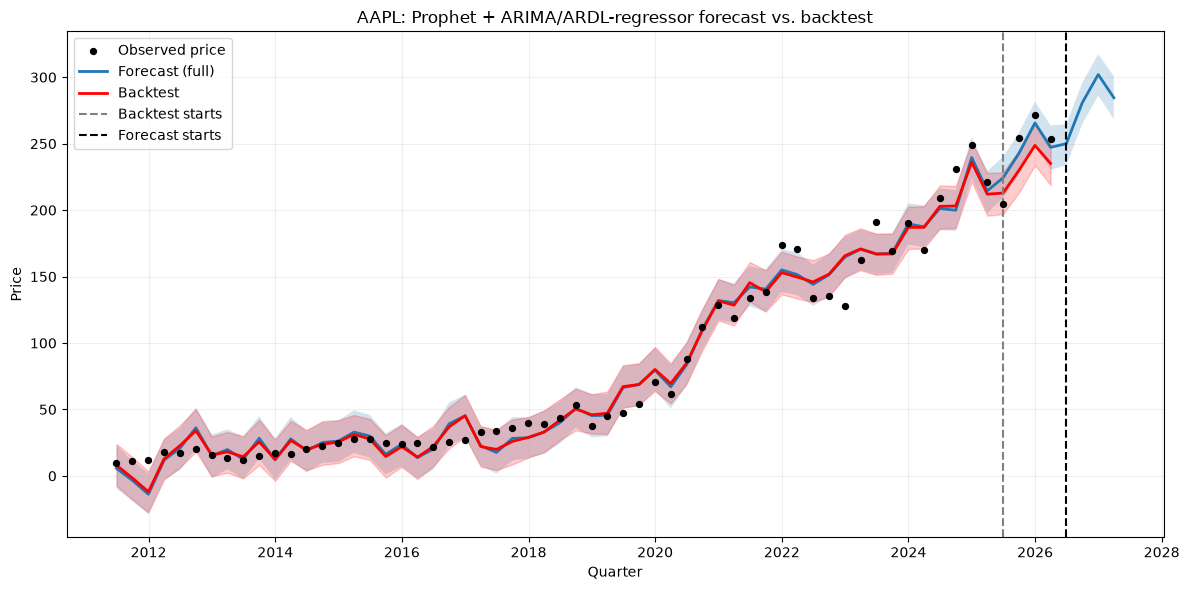

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))

actual_mask = ~results_full["is_future"]
ax.scatter(results_full.loc[actual_mask, "ds"], results_full.loc[actual_mask, "y"],
           s=18, color="k", zorder=3, label="Observed price")

ax.plot(results_full["ds"], results_full["yhat"], linewidth=2, label="Forecast (full)")
ax.fill_between(results_full["ds"], results_full["yhat_lower"], results_full["yhat_upper"], alpha=0.2)

ax.plot(results_bt["ds"], results_bt["yhat"], linewidth=2, color="red", label="Backtest")
ax.fill_between(results_bt["ds"], results_bt["yhat_lower"], results_bt["yhat_upper"], alpha=0.2, color="red")

bt_split = results_bt.loc[results_bt["is_future"], "ds"].min()
full_split = results_full.loc[results_full["is_future"], "ds"].min()
if pd.notna(bt_split):
    ax.axvline(bt_split, linestyle="--", color="gray", label="Backtest starts")
if pd.notna(full_split):
    ax.axvline(full_split, linestyle="--", color="black", label="Forecast starts")

ax.set_title(f"{TICKER}: Prophet + ARIMA/ARDL-regressor forecast vs. backtest")
ax.set_xlabel("Quarter"); ax.set_ylabel("Price")
handles, labels = ax.get_legend_handles_labels()
ax.legend(dict(zip(labels, handles)).values(), dict(zip(labels, handles)).keys(), loc="upper left")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## Notes / suggested next steps

- **Walk-forward backtesting**: this notebook does a single train/test split (last `BACKTEST_PERIODS`
  quarters), both for the Prophet backtest and for the ARIMA-vs-ARDL comparison in Step 5c. A
  rolling-origin backtest (re-fit at each step, forecast 1 quarter ahead, slide forward) would give
  a much more reliable error estimate than one split.
- **Propagate regressor uncertainty**: whichever model (ARIMA or ARDL) wins per metric, only its
  point forecast feeds Prophet — forecast intervals are discarded. Prophet's `yhat_upper`/`yhat_lower`
  therefore understate true uncertainty about the future, since they ignore the fact that the
  regressors themselves are forecasts (with growing error) for `ds` beyond the most recent observed
  quarter.
- **Log-transform price**: financial time series are usually fit better on a log scale (Prophet
  inherently does additive modeling); consider `y = log(price)` and exponentiate `yhat` back.
- **Multi-ticker run**: wrap `TICKER = ...` through Step 9 in a loop over `TICKER_SLUGS` to batch
  this across every company already tracked in this repo, accumulating one `results_full` row per
  ticker for a model comparison table.
- **Cache invalidation**: `fetch_fundamentals` / `fetch_macro_data` / `fetch_price_data` all cache to
  CSV indefinitely (`use_cache=True` by default). Pass `use_cache=False` to force a refresh, e.g. once
  a new quarter's earnings are out.
